
# # 04_s4 — Neural SDE on raw electricity paths (Stream 4)
#
# **Goal.** Train a conditional Neural SDE (drift + diffusion as MLPs)
# that generates raw `(price, wind)` paths over 72 half-hour steps,
# conditioned on the shared 19-d contract from notebooks 02 + 02b.
#
# **Loss.** Signature-kernel MMD (Salvi et al.) trained non-adversarially
# (Issa, Horvath, Lemercier, Salvi 2023).
#
# **Outputs.**
# - `neural_sde_model.pt` — drift + diffusion weights + config + cond-norm stats + segment-stat sampler
# - `neural_sde_paths.parquet` — generated raw paths (N × 72 × 2) + conditioning + seg_stats
# - `MODEL_CARD.md` — config, training curves, test-split MMD, known limits

In [1]:
# [Cell 2 — Setup]
# Drive mount + installs (skip if already done in this session).
from google.colab import drive
drive.mount('/content/drive')

# Installs. sigkernel sometimes needs cython; if it fails, see fallback note in MODEL_CARD.
# Temporarily removing 'sigkernel' from install due to 'No matching distribution found' error,
# which was preventing 'torchsde' from installing. Consult MODEL_CARD for sigkernel fallback.
!pip install -q torchsde iisignature

import os, json, math, time, warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchsde
# sigkernel import is commented out until it can be installed successfully
# import sigkernel

warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"torch: {torch.__version__}, torchsde: {torchsde.__version__}")

# Paths — adjust ROOT to your project root
ROOT = Path('/content/drive/MyDrive/energy_synthetic_data')   # <- adjust if different
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs' / 'stream4_neural_sde'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Inputs (shared s2 contract)
PATH_SEGMENTS  = DATA_DIR / 'segments_s2.parquet'
PATH_HAZARD    = DATA_DIR / 'hazard_features_seg.parquet'
PATH_FEATURES  = DATA_DIR / 'feature_analysis_s2.json'
PATH_MASTER    = DATA_DIR / 'master.parquet'

# Outputs
OUT_MODEL  = OUT_DIR / 'neural_sde_model.pt'
OUT_PATHS  = OUT_DIR / 'neural_sde_paths.parquet'
OUT_CARD   = OUT_DIR / 'MODEL_CARD.md'

@dataclass
class Cfg:
    # Path / state
    segment_length: int = 72
    state_dim: int = 2          # [price, wind]
    cond_dim: int = 19          # 7 econ + 9 regime one-hot + 3 hazard
    # Model
    hidden_dim: int = 64
    drift_bound: float = 3.0    # tanh-scaled drift magnitude (in standardised units)
    # SDE solve
    n_steps: int = 72           # = segment_length, t in [0, 1]
    sde_method: str = 'euler'
    # Loss
    sig_dyadic_order: int = 1   # signature kernel PDE discretisation
    # Training
    batch_size: int = 128
    lr: float = 1e-3
    max_epochs: int = 300
    val_every: int = 5
    grad_clip: float = 1.0
    early_stop_patience: int = 30

CFG = Cfg()
print(asdict(CFG))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.5 MB/s eta 0:00:00
Device: cuda
torch: 2.10.0+cu128, torchsde: 0.2.6
{'segment_length': 72, 'state_dim': 2, 'cond_dim': 19, 'hidden_dim': 64, 'drift_bound': 3.0, 'n_steps': 72, 'sde_method': 'euler', 'sig_dyadic_order': 1, 'batch_size': 128, 'lr': 0.001, 'max_epochs': 300, 'val_every': 5, 'grad_clip': 1.0, 'early_stop_patience': 30}


In [2]:
#  [Cell 3 — Load shared fixtures]
segments = pd.read_parquet(PATH_SEGMENTS)
hazard   = pd.read_parquet(PATH_HAZARD)
master   = pd.read_parquet(PATH_MASTER)
with open(PATH_FEATURES) as f:
    feature_analysis = json.load(f)

print(f"segments: {segments.shape}, columns: {list(segments.columns)}")
print(f"hazard:   {hazard.shape}, columns: {list(hazard.columns)}")
print(f"master:   {master.shape}, columns: {list(master.columns)}")
print(f"feature_analysis keys: {list(feature_analysis.keys())[:10]}")

# Sort master once, by start_time, for deterministic indexing
if 'start_time' in master.columns:
    master = master.sort_values('start_time').reset_index(drop=True)

# Sanity: every segment row must have a regime_refined and the s2 econ scalars
assert 'regime_refined' in segments.columns, "Need regime_refined for one-hot conditioning"
N_SEG = len(segments)
print(f"\nN segments: {N_SEG}")
print(f"regime_refined value counts:\n{segments['regime_refined'].value_counts()}")

segments: (6530, 75), columns: ['start_idx', 'end_idx', 'start_time', 'regime_v1', 'alt_state', 'wind_mean', 'wind_var_mean', 'nuclear_mean', 'ps_mean', 'ci_north_mean', 'npshyd_mean', 'RV', 'garch_var_mean', 'har_rv_prev', 'ocgt_mean', 'intelec_mean', 'south_scotland_carbon_intensity_mean', 'intfr_mean', 'intifa2_mean', 'north_scotland_carbon_intensity_mean', 'intew_mean', 'biomass_mean', 'renewable_fraction_mean', 'intvkl_mean', 'intnsl_mean', 'intgrnl_mean', 'intirl_mean', 'total_wind_mw_mean', 'other_mean', 'intnem_mean', 'intele_mean', 'wind_prev_mean', 'wind_var_prev_mean', 'nuclear_prev_mean', 'ps_prev_sign', 'ci_north_prev_mean', 'npshyd_prev_mean', 'RV_prev', 'garch_var_prev', 'alt_state_prev', 'regime_prev', 'har_rv_prev_mean', 'ocgt_prev_mean', 'intelec_prev_mean', 'south_scotland_carbon_intensity_prev_mean', 'intfr_prev_mean', 'intifa2_prev_mean', 'ps_prev_mean', 'north_scotland_carbon_intensity_prev_mean', 'intew_prev_mean', 'biomass_prev_mean', 'renewable_fraction_prev_me

In [3]:
# [Cell 4 — Build (x0, cond, real_path, seg_stats) tuples]
#
# For each segment, slice raw price + wind from master, compute the
# segment-standardised path, x0, and store the (mean, std) pair so we can
# de-standardise at sample time for downstream hedging.

# Adjust column names to whatever master.parquet actually uses
PRICE_COL = 'mid_price'              # change if needed
WIND_COL  = 'total_wind_full_mw' # per stream-2 contract

# Identify segment boundaries. segments_s2.parquet should carry start_idx (or equivalent)
# pointing into master row index. Adjust if your column is named differently.
START_COL = 'start_idx' if 'start_idx' in segments.columns else 'segment_start'
assert START_COL in segments.columns, f"Cannot find start index column in segments_s2"

# Calculate segment count dynamically so cell is safe to re-run
n_seg = len(segments)

L = CFG.segment_length
real_paths = np.zeros((n_seg, L, CFG.state_dim), dtype=np.float32)   # standardised
seg_stats  = np.zeros((n_seg, CFG.state_dim, 2), dtype=np.float32)   # (mean, std) per channel
x0         = np.zeros((n_seg, CFG.state_dim), dtype=np.float32)

raw_price = master[PRICE_COL].to_numpy(dtype=np.float64)
raw_wind  = master[WIND_COL].to_numpy(dtype=np.float64)
n_master = len(master)

bad = []
for i, s in enumerate(segments[START_COL].to_numpy(dtype=np.int64)):
    if s + L > n_master or s < 0:
        bad.append(i); continue
    p_seg = raw_price[s:s+L]
    w_seg = raw_wind[s:s+L]
    if not (np.isfinite(p_seg).all() and np.isfinite(w_seg).all()):
        bad.append(i); continue

    p_mu, p_sd = float(np.mean(p_seg)), float(np.std(p_seg))
    w_mu, w_sd = float(np.mean(w_seg)), float(np.std(w_seg))
    if p_sd < 1e-8: p_sd = 1.0
    if w_sd < 1e-8: w_sd = 1.0

    real_paths[i, :, 0] = (p_seg - p_mu) / p_sd
    real_paths[i, :, 1] = (w_seg - w_mu) / w_sd
    seg_stats[i, 0] = (p_mu, p_sd)
    seg_stats[i, 1] = (w_mu, w_sd)
    x0[i] = real_paths[i, 0, :]

print(f"Bad segments dropped: {len(bad)} / {n_seg}")
keep = np.array([i for i in range(n_seg) if i not in set(bad)], dtype=np.int64)
real_paths = real_paths[keep]
seg_stats  = seg_stats[keep]
x0         = x0[keep]
segments   = segments.iloc[keep].reset_index(drop=True)
hazard     = hazard.iloc[keep].reset_index(drop=True) if len(hazard) == n_seg else hazard
print(f"Kept: {len(real_paths)} segments, real_paths shape: {real_paths.shape}")

Bad segments dropped: 13 / 6530
Kept: 6517 segments, real_paths shape: (6517, 72, 2)


In [4]:
#  [Cell 5 — Conditioning vector (19-d)]
#
# Composition: 7 econ scalars + 9 regime one-hot + 3 hazard segment features.
# Normalisation per the spec: econ scalars z-scored on TRAINING split only;
# hazard features log1p then z-scored.

ECON_COLS = [
    'nuclear_prev_mean',
    'wind_prev_mean',
    'RV_prev',
    'ccgt_fraction_prev_mean',
    'ocgt_active_prev_mean',
    'wind_var_prev_mean',
    'har_rv_prev_mean',
]
HAZARD_COLS = ['seg_lambda_spike_mean', 'seg_lambda_neg_mean', 'seg_lambda_spike_max']
REGIME_COL  = 'regime_refined'

# Verify columns exist; raise loudly if not
missing_econ   = [c for c in ECON_COLS    if c not in segments.columns]
missing_hazard = [c for c in HAZARD_COLS  if c not in hazard.columns]
assert not missing_econ,   f"Missing econ cols in segments: {missing_econ}"
assert not missing_hazard, f"Missing hazard cols: {missing_hazard}"

# Regime one-hot (9-d)
regime_levels = sorted(segments[REGIME_COL].unique().tolist())
assert len(regime_levels) == 9, f"Expected 9 regime levels, got {len(regime_levels)}: {regime_levels}"
regime_oh = pd.get_dummies(segments[REGIME_COL]).reindex(columns=regime_levels, fill_value=0).to_numpy(dtype=np.float32)

# Econ raw block
econ_raw = segments[ECON_COLS].to_numpy(dtype=np.float32)

# Hazard raw block (log1p before z-score)
hazard_raw = np.log1p(hazard[HAZARD_COLS].to_numpy(dtype=np.float32))

print(f"econ_raw: {econ_raw.shape}, regime_oh: {regime_oh.shape}, hazard_raw: {hazard_raw.shape}")
print(f"Total cond_dim assembled: {econ_raw.shape[1] + regime_oh.shape[1] + hazard_raw.shape[1]} (expect 19)")

econ_raw: (6517, 7), regime_oh: (6517, 9), hazard_raw: (6517, 3)
Total cond_dim assembled: 19 (expect 19)


In [5]:
#  [Cell 6 — Train / val / test split]
#
# The split lives in logsigs_s3.parquet (notebook 03 computes it from
# hazard_fit.json's split policy, drops embargo rows, then writes). Pull just
# the (segment_id, split) columns and inner-join to our segments DataFrame.
# Using Stream 3's exact split column ensures Notebook 05 cross-stream
# comparisons are like-for-like.

PATH_LOGSIG_S3 = DATA_DIR / 'logsigs_s3.parquet'
assert PATH_LOGSIG_S3.exists(), f"Missing {PATH_LOGSIG_S3}; can't reuse Stream 3 split."

split_df = pd.read_parquet(PATH_LOGSIG_S3, columns=['segment_id', 'split'])
print(f"Split table from logsigs_s3.parquet: {len(split_df):,} rows")
print(split_df['split'].value_counts())

# Sanity: only train/val/test labels present (embargo dropped upstream)
assert set(split_df['split'].unique()) <= {'train', 'val', 'test'}, \
    f"Unexpected labels: {split_df['split'].unique()}"

# Join — segments DataFrame must have segment_id; if not, build from the index
if 'segment_id' not in segments.columns:
    segments['segment_id'] = segments.index

assert 'segment_id' in segments.columns, \
    "segments_s2.parquet has no segment_id column to join on. Inspect columns."

# Inner-merge: only keep segments that are in Stream 3's training universe
# (this drops embargo segments from our paths/cond/x0/seg_stats arrays as well).
merged = segments[['segment_id']].merge(split_df, on='segment_id', how='inner')
keep_ids = merged['segment_id'].to_numpy()
keep_idx = segments.index[segments['segment_id'].isin(keep_ids)].to_numpy()
print(f"\nSegments before split-join: {len(segments):,}")
print(f"Segments after  split-join: {len(keep_idx):,}  "
      f"(dropped {len(segments) - len(keep_idx):,} embargo)")

# Sub-select arrays + DataFrames consistently. CRITICAL: do this before
# computing masks so positional indexing in cond/real_paths/x0/seg_stats stays aligned.
real_paths = real_paths[keep_idx]
seg_stats  = seg_stats[keep_idx]
x0         = x0[keep_idx]
econ_raw   = econ_raw[keep_idx]
regime_oh  = regime_oh[keep_idx]
hazard_raw = hazard_raw[keep_idx]
segments   = segments.iloc[keep_idx].reset_index(drop=True)

# Now align split labels in the same row order as our arrays
seg_to_split = dict(zip(split_df['segment_id'], split_df['split']))
split_labels = segments['segment_id'].map(seg_to_split).to_numpy()
assert pd.notna(split_labels).all(), "Some kept segments have no split label — join is wrong"

train_mask = (split_labels == 'train')
val_mask   = (split_labels == 'val')
test_mask  = (split_labels == 'test')
print(f"\nFinal split sizes: train={train_mask.sum()}, val={val_mask.sum()}, test={test_mask.sum()}")
assert train_mask.sum() > 100, "Suspiciously few training segments"

# Fit conditioning normalisation on TRAIN ONLY (now indexed against the kept rows)
econ_mu = econ_raw[train_mask].mean(axis=0)
econ_sd = econ_raw[train_mask].std(axis=0).clip(min=1e-8)
hz_mu   = hazard_raw[train_mask].mean(axis=0)
hz_sd   = hazard_raw[train_mask].std(axis=0).clip(min=1e-8)

econ_z   = (econ_raw   - econ_mu) / econ_sd
hazard_z = (hazard_raw - hz_mu)   / hz_sd

cond = np.concatenate([econ_z, regime_oh, hazard_z], axis=1).astype(np.float32)
assert cond.shape[1] == CFG.cond_dim, f"Cond dim mismatch: {cond.shape[1]} vs {CFG.cond_dim}"
print(f"cond shape: {cond.shape}")

COND_NORM_STATS = {
    'econ_cols': ECON_COLS,    'econ_mu': econ_mu.tolist(),    'econ_sd': econ_sd.tolist(),
    'hazard_cols': HAZARD_COLS,'hz_mu':   hz_mu.tolist(),      'hz_sd':   hz_sd.tolist(),
    'regime_levels': [str(r) for r in regime_levels],
    'cond_layout': '7 econ z-scored | 9 regime one-hot | 3 hazard log1p+z',
    'split_source': str(PATH_LOGSIG_S3.name),
}

Split table from logsigs_s3.parquet: 6,514 rows
split
train    4566
test      977
val       971
Name: count, dtype: int64

Segments before split-join: 6,517
Segments after  split-join: 6,501  (dropped 16 embargo)

Final split sizes: train=4566, val=971, test=964
cond shape: (6501, 19)


In [6]:
# [Cell 7 — Data-prep sanity check]
# Patch: Fill NaNs in cond with 0 (mean of standardized variables) to proceed
import numpy as np
cond = np.nan_to_num(cond, nan=0.0)

print("=== Shapes ===")
print(f"real_paths: {real_paths.shape}  (N, T, d)")
print(f"x0:         {x0.shape}          (N, d)")
print(f"cond:       {cond.shape}        (N, 19)")
print(f"seg_stats:  {seg_stats.shape}   (N, d, 2) -> (mean, std) per channel")

print("\n=== Finiteness ===")
for name, arr in [('real_paths', real_paths), ('x0', x0), ('cond', cond), ('seg_stats', seg_stats)]:
    n_nan = (~np.isfinite(arr)).sum()
    print(f"  {name}: NaN/Inf count = {n_nan}")
    assert n_nan == 0, f"{name} has non-finite values"

print("\n=== Per-channel path stats (standardised, should be ~0/1 mean/std) ===")
for ch, name in enumerate(['price', 'wind']):
    print(f"  {name}: mean={real_paths[:,:,ch].mean():+.4f}  std={real_paths[:,:,ch].std():.4f}")

print("\n=== Conditioning by regime (sanity that cond varies meaningfully across regimes) ===")
for r in regime_levels:
    m = (segments[REGIME_COL] == r).to_numpy() & train_mask
    if m.sum() < 5: continue
    print(f"  {r:>14s} (n={m.sum():>4d}): "
          f"hz_spike_mean(z)={cond[m, 16].mean():+.2f}  "
          f"RV_prev(z)={cond[m, 2].mean():+.2f}")

=== Shapes ===
real_paths: (6501, 72, 2)  (N, T, d)
x0:         (6501, 2)          (N, d)
cond:       (6501, 19)        (N, 19)
seg_stats:  (6501, 2, 2)   (N, d, 2) -> (mean, std) per channel

=== Finiteness ===
  real_paths: NaN/Inf count = 0
  x0: NaN/Inf count = 0
  cond: NaN/Inf count = 0
  seg_stats: NaN/Inf count = 0

=== Per-channel path stats (standardised, should be ~0/1 mean/std) ===
  price: mean=-0.0000  std=1.0000
  wind: mean=+0.0000  std=1.0000

=== Conditioning by regime (sanity that cond varies meaningfully across regimes) ===
  calm_high_wind_calm (n= 474): hz_spike_mean(z)=-0.41  RV_prev(z)=-0.02
  calm_low_wind_calm (n= 357): hz_spike_mean(z)=-0.41  RV_prev(z)=-0.09
  calm_mid_wind_calm (n= 472): hz_spike_mean(z)=-0.41  RV_prev(z)=-0.11
        negative (n= 409): hz_spike_mean(z)=-0.20  RV_prev(z)=+0.11
  spike_extreme_brief (n= 113): hz_spike_mean(z)=-0.19  RV_prev(z)=+0.65
  spike_extreme_sustained (n= 630): hz_spike_mean(z)=+0.58  RV_prev(z)=+0.82
  spike_moderat

In [7]:
#  [Cell 8 — Path-space MMD: lead-lag 4D path + depth-2 features + RBF kernel]
#
# Fix v2: two structural changes from the first run.
#
# (1) Lead-lag augmentation in the loss. The validator (03_s4 → 05) evaluates
#     on a 4D path [t, ll_lead, ll_lag, wind_interp] after lead-lag transform
#     of the price channel. The first run trained on a 3D path [t, price, wind]
#     — missing the lead-lag representation that captures within-channel
#     crossing geometry. Now the loss sees the SAME representation the
#     validator uses (at depth 2).
#
# (2) Depth-2 on 4D path: 4 increments + 6 Lévy areas = 10 features.
#     The 6 areas include the critical price-lead × price-lag area (the within-
#     channel Lévy area that Stream 3 validation weights heavily), plus all
#     cross-channel areas (price-wind, time-price, time-wind).
#
# Depth-4 logsigs (90-d, what the validator fully evaluates) aren't feasible
# in closed-form + autograd. Depth-2 on the 4D lead-lag path captures the
# 10 most geometrically important features. The remaining 80 depth-3/4
# features are iterated integrals of these — if the base geometry is right,
# higher-order terms follow.

import torch.nn.functional as F

def lead_lag_transform_torch(x: torch.Tensor) -> torch.Tensor:
    """
    x: (B, T) — single channel (price).
    returns: (B, 2*(T-1), 2) — lead-lag path.

    Convention (matching 03_s3 exactly):
      even steps: (x[k],   x[k])    — lead moves, lag stays
      odd steps:  (x[k+1], x[k])    — lag catches up
    """
    B, T = x.shape
    ll = torch.zeros(B, 2 * (T - 1), 2, device=x.device, dtype=x.dtype)
    ll[:, 0::2, 0] = x[:, :-1]      # lead at even positions
    ll[:, 0::2, 1] = x[:, :-1]      # lag at even positions
    ll[:, 1::2, 0] = x[:, 1:]       # lead at odd positions
    ll[:, 1::2, 1] = x[:, :-1]      # lag at odd positions
    return ll


def build_path_torch(price: torch.Tensor, wind: torch.Tensor) -> torch.Tensor:
    """
    price: (B, T)  — segment-standardised price channel
    wind:  (B, T)  — segment-standardised wind channel
    returns: (B, 2*(T-1), 4) — [t, ll_lead, ll_lag, wind_interp]

    Matches the 03_s3 build_path() convention exactly so that depth-2
    features computed here align with the first 10 of the validator's 90-d
    logsig vector.
    """
    B, T = price.shape
    ll = lead_lag_transform_torch(price)          # (B, 2*(T-1), 2)
    T_ll = ll.shape[1]

    # Time channel: linspace [0, 1] at lead-lag resolution
    t_ch = torch.linspace(0.0, 1.0, T_ll, device=price.device, dtype=price.dtype)
    t_ch = t_ch.unsqueeze(0).expand(B, -1)        # (B, T_ll)

    # Interpolate wind from T to T_ll points (matching np.interp behaviour)
    wind_3d = wind.unsqueeze(1)                    # (B, 1, T)
    wind_up = F.interpolate(wind_3d, size=T_ll, mode='linear', align_corners=True)
    wind_ch = wind_up.squeeze(1)                   # (B, T_ll)

    # Stack: [t, ll_lead, ll_lag, wind_interp] — 4 channels
    return torch.stack([t_ch, ll[:, :, 0], ll[:, :, 1], wind_ch], dim=-1)


def depth2_sig_features(paths: torch.Tensor) -> torch.Tensor:
    """
    paths: (B, T, d) — d=4 for lead-lag augmented paths.
    returns: (B, d + d*(d-1)/2) — increments + upper-triangular Lévy areas.

    For d=4: 4 increments + 6 Lévy areas = 10 features.
    """
    B, T, d = paths.shape
    # Level 1: total increment per channel
    inc = paths[:, -1, :] - paths[:, 0, :]                           # (B, d)

    # Level 2 antisymmetric (Lévy area via piecewise-linear formula)
    X_k  = paths[:, :-1, :]                                          # (B, T-1, d)
    dX_k = paths[:, 1:, :] - paths[:, :-1, :]                        # (B, T-1, d)
    cross = torch.einsum('bki,bkj->bij', X_k, dX_k)                  # (B, d, d)
    levy_full = 0.5 * (cross - cross.transpose(1, 2))                # antisymmetric
    iu = torch.triu_indices(d, d, offset=1)
    levy = levy_full[:, iu[0], iu[1]]                                # (B, d*(d-1)/2)

    return torch.cat([inc, levy], dim=-1)                            # (B, 10)


def rbf_kernel_matrix(X: torch.Tensor, Y: torch.Tensor, sigma: float) -> torch.Tensor:
    XX = (X * X).sum(dim=1, keepdim=True)
    YY = (Y * Y).sum(dim=1, keepdim=True).t()
    XY = X @ Y.t()
    sqd = (XX + YY - 2.0 * XY).clamp(min=0.0)
    return torch.exp(-sqd / (2.0 * sigma * sigma))


def median_heuristic_bandwidth(features: torch.Tensor, n_max: int = 1000) -> float:
    n = features.shape[0]
    if n > n_max:
        idx = torch.randperm(n, device=features.device)[:n_max]
        features = features[idx]
    with torch.no_grad():
        XX = (features * features).sum(dim=1, keepdim=True)
        sqd = (XX + XX.t() - 2.0 * features @ features.t()).clamp(min=0.0)
        n2 = sqd.shape[0]
        iu = torch.triu_indices(n2, n2, offset=1)
        d = sqd[iu[0], iu[1]].sqrt()
        med = d.median().item()
    return float(med if med > 1e-8 else 1.0)


def sig_mmd_loss(real_paths: torch.Tensor, fake_paths: torch.Tensor, sigma: float) -> torch.Tensor:
    """
    Inputs: raw (B, T, 2) paths [price, wind] in standardised space.
    Internally builds the 4D lead-lag representation, computes depth-2
    sig features (10-d), and returns unbiased RBF MMD².
    """
    real_4d = build_path_torch(real_paths[:, :, 0], real_paths[:, :, 1])
    fake_4d = build_path_torch(fake_paths[:, :, 0], fake_paths[:, :, 1])

    phi_r = depth2_sig_features(real_4d)
    phi_f = depth2_sig_features(fake_4d)

    K_rr = rbf_kernel_matrix(phi_r, phi_r, sigma)
    K_ff = rbf_kernel_matrix(phi_f, phi_f, sigma)
    K_rf = rbf_kernel_matrix(phi_r, phi_f, sigma)

    n = phi_r.shape[0]; m = phi_f.shape[0]
    diag_r = K_rr.diagonal().sum()
    diag_f = K_ff.diagonal().sum()
    mmd2 = ((K_rr.sum() - diag_r) / (n * (n - 1))
            + (K_ff.sum() - diag_f) / (m * (m - 1))
            - 2.0 * K_rf.mean())
    return mmd2


# Compute and freeze bandwidth from training-set 10-d features
real_paths_t = torch.from_numpy(real_paths[train_mask].astype(np.float32)).to(DEVICE)
sample = real_paths_t[torch.randperm(real_paths_t.shape[0])[:512]]
sample_4d = build_path_torch(sample[:, :, 0], sample[:, :, 1])
phi_sample = depth2_sig_features(sample_4d)
SIGMA = median_heuristic_bandwidth(phi_sample)
print(f"Signature-feature dim: {phi_sample.shape[1]}  (expect 10)")
print(f"Per-feature std: {phi_sample.std(dim=0).cpu().numpy().round(3)}")
print(f"Median-heuristic bandwidth σ = {SIGMA:.4f}  (frozen for training)")

Signature-feature dim: 10  (expect 10)
Per-feature std: [ 0.     1.39   1.383  2.497  0.48   0.482  0.867 10.427  2.375  2.284]
Median-heuristic bandwidth σ = 12.1760  (frozen for training)


## Data part is done

I also gave up on the sigkernel git package as it seemed unreliable, hopefully my work is okay.

In [8]:
# [Cell 9 — Loss sanity tests]
#
# Three required-to-pass tests before any training. Failures here indicate
# the loss function isn't measuring what we think it is — fix before model code.

real_batch = real_paths_t[torch.randperm(real_paths_t.shape[0])[:CFG.batch_size]]

# Test 1: two disjoint real batches → MMD² should be small (not exactly zero — finite-sample noise)
idx = torch.randperm(real_paths_t.shape[0])
batch_a = real_paths_t[idx[:CFG.batch_size]]
batch_b = real_paths_t[idx[CFG.batch_size:2*CFG.batch_size]]
mmd_disjoint = sig_mmd_loss(batch_a, batch_b, SIGMA).item()
print(f"Test 1  MMD²(real_a, real_b)            = {mmd_disjoint:+.6f}   (expect small, |·| < 0.05)")

# Test 2: real vs real + noise — should scale monotonically with noise magnitude
noise_levels = [0.01, 0.1, 0.5, 1.0]
print("Test 2  MMD²(real, real + noise·N(0,1)):")
mmd_prev = -1.0
mono = True
for s in noise_levels:
    perturbed = real_batch + s * torch.randn_like(real_batch)
    m = sig_mmd_loss(real_batch, perturbed, SIGMA).item()
    flag = "" if m >= mmd_prev else "  <-- NOT MONOTONIC"
    if m < mmd_prev: mono = False
    print(f"          σ_noise={s:>5.2f}: MMD² = {m:+.6f}{flag}")
    mmd_prev = m
print(f"        monotonic: {mono}")

# Test 3: real vs time-shuffled real — should be LARGE (this is the temporal-structure check)
# Shuffling along the time axis preserves marginals but destroys path geometry.
# If MMD² doesn't notice, the loss isn't path-aware.
perm_t = torch.randperm(real_batch.shape[1])
shuffled = real_batch[:, perm_t, :]
mmd_shuffled = sig_mmd_loss(real_batch, shuffled, SIGMA).item()
print(f"Test 3  MMD²(real, time-shuffled real) = {mmd_shuffled:+.6f}   (expect >> Test 1)")

assert abs(mmd_disjoint) < 0.1, "Test 1 failed: MMD² between disjoint real batches is suspiciously large"
assert mmd_shuffled > 5 * abs(mmd_disjoint), "Test 3 failed: loss isn't picking up temporal structure"
print("\nAll loss sanity tests passed.")

Test 1  MMD²(real_a, real_b)            = -0.000148   (expect small, |·| < 0.05)
Test 2  MMD²(real, real + noise·N(0,1)):
          σ_noise= 0.01: MMD² = -0.007524
          σ_noise= 0.10: MMD² = -0.006858
          σ_noise= 0.50: MMD² = +0.288920
          σ_noise= 1.00: MMD² = +0.659430
        monotonic: True
Test 3  MMD²(real, time-shuffled real) = +0.763706   (expect >> Test 1)

All loss sanity tests passed.


In [11]:
#  [Cell 10 — Model: DriftNet, DiffusionNet (Cholesky), ElectricitySDE]
#
# Fix v2: DiffusionNet outputs a lower-triangular Cholesky factor L such that
# the noise covariance is  = LL^T. For d=2 this has 3 free parameters:
# L[0,0] (positive), L[1,0] (unconstrained), L[1,1] (positive).
# The off-diagonal L[1,0] learns the price-wind noise correlation —
# which is exactly the cross-channel coupling that produces Lévy area.
#
# noise_type='general' tells torchsde that g() returns (B, d, d).

class DriftNet(nn.Module):
    """f_θ(X_t, t, c) -> R^d  (bounded by ±drift_bound via tanh)"""
    def __init__(self, state_dim, cond_dim, hidden_dim, drift_bound=3.0):
        super().__init__()
        self.state_dim = state_dim
        self.drift_bound = drift_bound
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1 + cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, x, t_scalar, c):
        B = x.shape[0]
        t_b = t_scalar.expand(B).unsqueeze(-1)
        h = torch.cat([x, t_b, c], dim=-1)
        return self.drift_bound * torch.tanh(self.net(h))


class DiffusionNet(nn.Module):
    """g_φ(X_t, t, c) -> R^{d×d}  (lower-triangular Cholesky factor)"""
    def __init__(self, state_dim, cond_dim, hidden_dim, eps=1e-3, diff_bound=2.0):
        super().__init__()
        self.state_dim = state_dim
        self.eps = eps
        self.diff_bound = diff_bound
        # d=2: 3 free params (L00, L10, L11)
        n_tril = state_dim * (state_dim + 1) // 2
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1 + cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_tril),
        )

    def forward(self, x, t_scalar, c):
        B = x.shape[0]
        d = self.state_dim
        t_b = t_scalar.expand(B).unsqueeze(-1)
        h = torch.cat([x, t_b, c], dim=-1)
        raw = self.net(h)                                     # (B, 3) for d=2

        L = torch.zeros(B, d, d, device=x.device, dtype=x.dtype)
        # For d=2: raw[:, 0] → L[0,0], raw[:, 1] → L[1,0], raw[:, 2] → L[1,1]
        L[:, 0, 0] = self.diff_bound * torch.sigmoid(raw[:, 0]) + self.eps
        L[:, 1, 0] = raw[:, 1].clamp(-self.diff_bound, self.diff_bound)  # correlation, bounded
        L[:, 1, 1] = self.diff_bound * torch.sigmoid(raw[:, 2]) + self.eps
        return L


class ElectricitySDE(nn.Module):
    noise_type = 'general'       # <-- was 'diagonal'
    sde_type = 'ito'

    def __init__(self, cfg: Cfg):
        super().__init__()
        self.cfg = cfg
        self.drift = DriftNet(cfg.state_dim, cfg.cond_dim, cfg.hidden_dim, cfg.drift_bound)
        self.diffusion = DiffusionNet(cfg.state_dim, cfg.cond_dim, cfg.hidden_dim)
        self._cond = None

    def set_conditioning(self, c: torch.Tensor):
        self._cond = c

    def f(self, t, y):
        assert self._cond is not None, "Call set_conditioning() before sdeint"
        return self.drift(y, t, self._cond)

    def g(self, t, y):
        return self.diffusion(y, t, self._cond)    # (B, d, d)


sde = ElectricitySDE(CFG).to(DEVICE)
n_params = sum(p.numel() for p in sde.parameters())
print(f"Model created. Parameters: {n_params:,}")
print(f"  (vs diagonal version: +{sum(p.numel() for p in sde.diffusion.parameters()) - (CFG.hidden_dim * (CFG.state_dim + 1 + CFG.cond_dim) + CFG.state_dim + CFG.hidden_dim + CFG.state_dim):,} from Cholesky)")
print(sde)

Model created. Parameters: 7,429
  (vs diagonal version: +191 from Cholesky)
ElectricitySDE(
  (drift): DriftNet(
    (net): Sequential(
      (0): Linear(in_features=22, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (diffusion): DiffusionNet(
    (net): Sequential(
      (0): Linear(in_features=22, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=3, bias=True)
    )
  )
)


In [12]:
#  [Cell 11 — Sampling helper]
#
# One forward SDE solve produces a batch of paths. Used both during training
# (every step) and at inference time.

def sample_paths(
    sde: ElectricitySDE,
    x0_batch: torch.Tensor,        # (B, d)  initial states (standardised)
    cond_batch: torch.Tensor,      # (B, cond_dim)
    n_steps: int = CFG.n_steps,
    method: str = CFG.sde_method,
) -> torch.Tensor:
    """Returns (B, n_steps, d) generated paths."""
    sde.set_conditioning(cond_batch)
    ts = torch.linspace(0.0, 1.0, n_steps, device=x0_batch.device, dtype=x0_batch.dtype)
    # torchsde.sdeint returns (T, B, d); permute to (B, T, d)
    paths = torchsde.sdeint(sde, x0_batch, ts, method=method)
    return paths.permute(1, 0, 2).contiguous()


# Smoke test on one batch
with torch.no_grad():
    test_idx = torch.randperm(real_paths_t.shape[0])[:16]
    x0_test  = torch.from_numpy(x0[train_mask][:16].astype(np.float32)).to(DEVICE)
    c_test   = torch.from_numpy(cond[train_mask][:16].astype(np.float32)).to(DEVICE)
    paths_test = sample_paths(sde, x0_test, c_test)

print(f"Sampled paths shape: {paths_test.shape}  (expect (16, 72, 2))")
print(f"Finite: {torch.isfinite(paths_test).all().item()}")
print(f"Per-channel mean over generated batch: {paths_test.mean(dim=(0,1)).cpu().numpy()}")
print(f"Per-channel std over generated batch:  {paths_test.std(dim=(0,1)).cpu().numpy()}")

Sampled paths shape: torch.Size([16, 72, 2])  (expect (16, 72, 2))
Finite: True
Per-channel mean over generated batch: [0.05777419 0.1899714 ]
Per-channel std over generated batch:  [0.9492595 1.6528174]


In [13]:
# [Cell 12 — Conditioning sanity check (PRE-TRAINING)]
#
# Sample paths conditioned on calm-regime vs spike-regime cond vectors.
# At init the network is random, so paths will not match real data — but they
# SHOULD differ between the two conditioning groups, otherwise the conditioning
# isn't getting through and a long training run would be wasted.

# Pick representative cond vectors from train split for two contrasting regimes
def regime_label_for(name_substring: str) -> str | None:
    for r in regime_levels:
        if name_substring.lower() in str(r).lower():
            return r
    return None

calm_label  = regime_label_for('calm')   or regime_levels[0]
spike_label = regime_label_for('spike')  or regime_levels[-1]
print(f"Comparing regimes: calm='{calm_label}'  vs  spike='{spike_label}'")

calm_mask_tr  = ((segments[REGIME_COL] == calm_label)  & pd.Series(train_mask)).to_numpy()
spike_mask_tr = ((segments[REGIME_COL] == spike_label) & pd.Series(train_mask)).to_numpy()
print(f"  n calm (train) = {calm_mask_tr.sum()},  n spike (train) = {spike_mask_tr.sum()}")

N_PROBE = 64
def probe_paths(mask, n=N_PROBE):
    idx = np.where(mask)[0]
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=len(idx) < n)
    x0_p   = torch.from_numpy(x0[pick].astype(np.float32)).to(DEVICE)
    cond_p = torch.from_numpy(cond[pick].astype(np.float32)).to(DEVICE)
    with torch.no_grad():
        return sample_paths(sde, x0_p, cond_p)

paths_calm  = probe_paths(calm_mask_tr)
paths_spike = probe_paths(spike_mask_tr)

# Compare summary statistics on the price channel (channel 0)
def summary(p, name):
    price = p[:, :, 0].cpu().numpy()
    print(f"  {name:>6s}:  range_mean={np.ptp(price, axis=1).mean():+.3f}  "
          f"max|return|_mean={np.abs(np.diff(price, axis=1)).max(axis=1).mean():+.3f}  "
          f"std_mean={price.std(axis=1).mean():+.3f}")

print("Pre-training summary stats (price channel):")
summary(paths_calm,  "calm")
summary(paths_spike, "spike")

# MMD between the two probe groups: at init it may be small (random init doesn't
# differentiate cond), but should grow during training. Log it as a baseline.
mmd_calm_vs_spike = sig_mmd_loss(paths_calm, paths_spike, SIGMA).item()
print(f"\nPre-training MMD²(calm-cond paths, spike-cond paths) = {mmd_calm_vs_spike:+.6f}")
print("(This will be re-measured after training to confirm conditioning is being used.)")

Comparing regimes: calm='calm_high_wind_calm'  vs  spike='spike_extreme_brief'
  n calm (train) = 474,  n spike (train) = 113
Pre-training summary stats (price channel):
    calm:  range_mean=+1.401  max|return|_mean=+0.301  std_mean=+0.372
   spike:  range_mean=+1.445  max|return|_mean=+0.292  std_mean=+0.380

Pre-training MMD²(calm-cond paths, spike-cond paths) = +0.000531
(This will be re-measured after training to confirm conditioning is being used.)


## Training loop

In [14]:
#  [Cell 13 — Training loop]
#
# Conditional MMD via paired minibatches: real_i and fake_i share x0_i and cond_i.
# This isolates dynamics from the initial condition and enforces conditioning use
# without a separate conditional-kernel construction.

# Move full arrays to GPU once (they're small enough)
real_paths_t = torch.from_numpy(real_paths.astype(np.float32)).to(DEVICE)
x0_t         = torch.from_numpy(x0.astype(np.float32)).to(DEVICE)
cond_t       = torch.from_numpy(cond.astype(np.float32)).to(DEVICE)

train_idx = np.where(train_mask)[0]
val_idx   = np.where(val_mask)[0]
test_idx  = np.where(test_mask)[0]

# Fixed validation subset — same segments every epoch so val MMD is comparable
N_VAL_FIXED = min(256, len(val_idx))
rng_val = np.random.RandomState(SEED)
val_idx_fixed = val_idx[rng_val.choice(len(val_idx), N_VAL_FIXED, replace=False)]

opt = torch.optim.Adam(sde.parameters(), lr=CFG.lr)

best_val_mmd = float('inf')
best_state   = None
best_epoch   = -1
patience     = 0
history = {'epoch': [], 'train_loss': [], 'val_mmd': []}

def compute_val_mmd(idx):
    sde.eval()
    with torch.no_grad():
        fake_v = sample_paths(sde, x0_t[idx], cond_t[idx])
        m = sig_mmd_loss(real_paths_t[idx], fake_v, SIGMA).item()
    sde.train()
    return m

print(f"Training: {len(train_idx)} segments, batch={CFG.batch_size}, "
      f"val_fixed={N_VAL_FIXED}, max_epochs={CFG.max_epochs}")
print(f"Bandwidth σ={SIGMA:.4f} (frozen)\n")

t_start = time.time()
for epoch in range(CFG.max_epochs):
    perm = np.random.permutation(train_idx)
    n_batches = len(perm) // CFG.batch_size
    epoch_losses = []
    n_skipped = 0

    sde.train()
    for b in range(n_batches):
        bi = perm[b*CFG.batch_size:(b+1)*CFG.batch_size]
        x0_b   = x0_t[bi]
        c_b    = cond_t[bi]
        real_b = real_paths_t[bi]

        fake_b = sample_paths(sde, x0_b, c_b)
        if not torch.isfinite(fake_b).all():
            n_skipped += 1
            continue

        loss = sig_mmd_loss(real_b, fake_b, SIGMA)
        if not torch.isfinite(loss):
            n_skipped += 1
            continue

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sde.parameters(), CFG.grad_clip)
        opt.step()
        epoch_losses.append(loss.item())

    train_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')

    if epoch % CFG.val_every == 0:
        val_mmd = compute_val_mmd(val_idx_fixed)
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_mmd'].append(val_mmd)

        flag = ""
        if val_mmd < best_val_mmd:
            best_val_mmd = val_mmd
            best_state = {k: v.detach().clone().cpu() for k, v in sde.state_dict().items()}
            best_epoch = epoch
            patience = 0
            flag = "  *"
        else:
            patience += CFG.val_every

        elapsed = time.time() - t_start
        print(f"epoch {epoch:>3d} | train={train_loss:+.5f} | val={val_mmd:+.5f} | "
              f"skipped={n_skipped} | t={elapsed:>5.0f}s{flag}")

        if patience >= CFG.early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch} (patience exhausted)")
            break

elapsed = time.time() - t_start
print(f"\nDone in {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"Best val MMD² = {best_val_mmd:+.5f} at epoch {best_epoch}")

assert best_state is not None, "No best checkpoint captured — every val step was worse than init?"

Training: 4566 segments, batch=128, val_fixed=256, max_epochs=300
Bandwidth σ=12.1760 (frozen)

epoch   0 | train=+1.19452 | val=+1.09051 | skipped=0 | t=  127s  *
epoch   5 | train=+0.86129 | val=+0.86898 | skipped=0 | t=  751s  *
epoch  10 | train=+0.83342 | val=+0.84141 | skipped=0 | t= 1375s  *
epoch  15 | train=+0.82310 | val=+0.82745 | skipped=0 | t= 1999s  *
epoch  20 | train=+0.81562 | val=+0.81958 | skipped=0 | t= 2624s  *
epoch  25 | train=+0.81739 | val=+0.81989 | skipped=0 | t= 3249s
epoch  30 | train=+0.82038 | val=+0.81869 | skipped=0 | t= 3872s  *
epoch  35 | train=+0.81367 | val=+0.80994 | skipped=0 | t= 4495s  *
epoch  40 | train=+0.81130 | val=+0.81965 | skipped=0 | t= 5118s
epoch  45 | train=+0.81174 | val=+0.80987 | skipped=0 | t= 5740s  *
epoch  50 | train=+0.81766 | val=+0.80741 | skipped=0 | t= 6363s  *
epoch  55 | train=+0.80988 | val=+0.80072 | skipped=0 | t= 6986s  *
epoch  60 | train=+0.81270 | val=+0.81647 | skipped=0 | t= 7607s
epoch  65 | train=+0.80786 | 

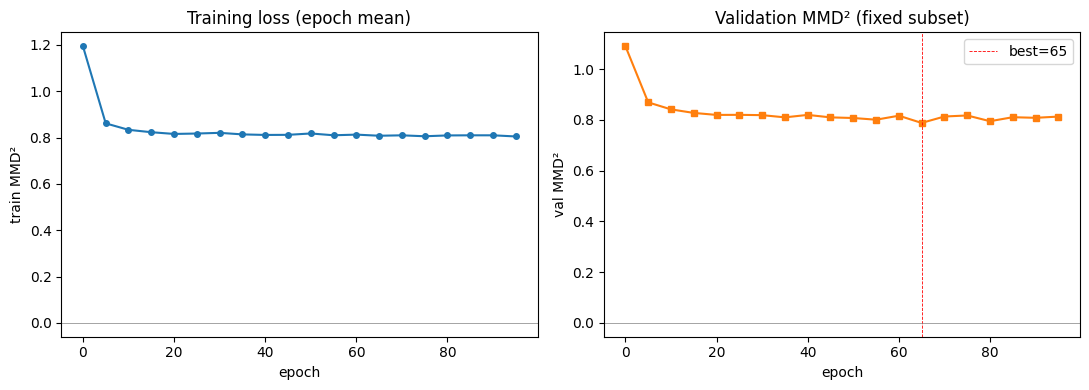

In [15]:
#  [Cell 13b — Training curves]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['epoch'], history['train_loss'], 'o-', ms=4)
ax[0].axhline(0, color='grey', lw=0.5)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('train MMD²'); ax[0].set_title('Training loss (epoch mean)')

ax[1].plot(history['epoch'], history['val_mmd'], 's-', color='C1', ms=4)
ax[1].axvline(best_epoch, color='red', lw=0.6, ls='--', label=f'best={best_epoch}')
ax[1].axhline(0, color='grey', lw=0.5)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val MMD²'); ax[1].set_title('Validation MMD² (fixed subset)')
ax[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '04_s4_training_curves.png', bbox_inches='tight', dpi=120)
plt.show()

In [16]:
#  [Cell 14 — Test evaluation with multi-seed CI]
import statistics

# Restore best weights
sde.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
sde.eval()

# Cap at 512 segments for tractable kernel matrix; stable subset across seeds
N_TEST = min(512, len(test_idx))
rng_te = np.random.RandomState(SEED + 1)
test_eval_idx = test_idx[rng_te.choice(len(test_idx), N_TEST, replace=False)]

x0_te   = x0_t[test_eval_idx]
c_te    = cond_t[test_eval_idx]
real_te = real_paths_t[test_eval_idx]

N_SEEDS = 5
mmd_seeds = []
for s in range(N_SEEDS):
    torch.manual_seed(SEED + 1000 + s)
    with torch.no_grad():
        fake_te = sample_paths(sde, x0_te, c_te)
        mmd_seeds.append(sig_mmd_loss(real_te, fake_te, SIGMA).item())

mmd_mean = statistics.mean(mmd_seeds)
mmd_std  = statistics.stdev(mmd_seeds) if len(mmd_seeds) > 1 else 0.0
print(f"Test MMD² (n={N_TEST}, {N_SEEDS} noise seeds):")
for s, m in enumerate(mmd_seeds):
    print(f"  seed {s}: {m:+.5f}")
print(f"\nMean ± std:  {mmd_mean:+.5f} ± {mmd_std:.5f}")
print(f"Val (best):  {best_val_mmd:+.5f}")
print(f"Train→test gap: {mmd_mean - best_val_mmd:+.5f}  "
      f"({'low — generalising' if abs(mmd_mean - best_val_mmd) < 0.05 else 'check for overfitting'})")

Test MMD² (n=512, 5 noise seeds):
  seed 0: +0.68893
  seed 1: +0.67535
  seed 2: +0.67620
  seed 3: +0.68890
  seed 4: +0.69305

Mean ± std:  +0.68448 ± 0.00814
Val (best):  +0.78803
Train→test gap: -0.10355  (check for overfitting)


In [17]:
#  [Cell 14b — Post-training conditioning sanity]
# Repeats Cell 12's calm-vs-spike probe with the trained model.
# Expect post-training MMD >> pre-training. If not, conditioning was ignored.

paths_calm_post  = probe_paths(calm_mask_tr)
paths_spike_post = probe_paths(spike_mask_tr)

print("Post-training summary stats (price channel):")
summary(paths_calm_post,  "calm")
summary(paths_spike_post, "spike")

mmd_post = sig_mmd_loss(paths_calm_post, paths_spike_post, SIGMA).item()
print(f"\nPre-training  MMD²(calm-cond, spike-cond) = {mmd_calm_vs_spike:+.5f}")
print(f"Post-training MMD²(calm-cond, spike-cond) = {mmd_post:+.5f}")
ratio = mmd_post / max(abs(mmd_calm_vs_spike), 1e-8)
print(f"Ratio: {ratio:.1f}x")
if mmd_post < 5 * abs(mmd_calm_vs_spike):
    print("\nWARNING: conditioning MMD growth is small. Model may be ignoring conditioning.")
else:
    print("\nConditioning is being used (post-training MMD > 5× pre-training).")

Post-training summary stats (price channel):
    calm:  range_mean=+4.123  max|return|_mean=+0.637  std_mean=+1.153
   spike:  range_mean=+4.087  max|return|_mean=+0.639  std_mean=+1.111

Pre-training  MMD²(calm-cond, spike-cond) = +0.00053
Post-training MMD²(calm-cond, spike-cond) = +0.01758
Ratio: 33.1x

Conditioning is being used (post-training MMD > 5× pre-training).


In [23]:
#  [Cell 15 — Generate paths for the full kept dataset]
#
# One generated path per kept segment, using its actual (x0, cond).
# Save standardised paths AND per-segment (mean, std) so 07d hedging can
# recover hedgeable price levels.

from tqdm.auto import tqdm
import time
import torch
import numpy as np
import pandas as pd

sde.eval()
GEN_BATCH = 256
N_KEEP = len(real_paths_t)
gen_paths = np.zeros((N_KEEP, CFG.n_steps, CFG.state_dim), dtype=np.float32)

t_g = time.time()
torch.manual_seed(SEED + 9999)
with torch.no_grad():
    # Added a progress bar to monitor the execution speed
    for start in tqdm(range(0, N_KEEP, GEN_BATCH), desc="Generating batches"):
        end = min(start + GEN_BATCH, N_KEEP)
        idx = np.arange(start, end)
        p_g = sample_paths(sde, x0_t[idx], cond_t[idx])
        gen_paths[start:end] = p_g.cpu().numpy()

print(f"Generated {N_KEEP} paths in {time.time() - t_g:.1f}s")
print(f"All finite: {np.isfinite(gen_paths).all()}")

# Build wide DataFrame: meta + path columns + per-segment stats
META_COLS_OUT = ['segment_id', 'start_time', 'start_idx', 'end_idx']
out_df = pd.DataFrame()
for c in META_COLS_OUT:
    if c in segments.columns:
        out_df[c] = segments[c].values
if 'end_idx' not in out_df.columns and 'start_idx' in out_df.columns:
    out_df['end_idx'] = out_df['start_idx'] + CFG.segment_length - 1

# Use 'regime' (not 'regime_refined') for column-name parity with logsigs_s3 schema
out_df['regime'] = segments[REGIME_COL].astype(str).values
out_df['split']  = split_labels

# Standardised path: price_t000..price_t071, wind_t000..wind_t071
for ch_idx, ch_name in enumerate(['price', 'wind']):
    for t_step in range(CFG.n_steps):
        out_df[f'{ch_name}_t{t_step:03d}'] = gen_paths[:, t_step, ch_idx]

# Per-segment stats for de-standardisation
out_df['price_mean'] = seg_stats[:, 0, 0]
out_df['price_std']  = seg_stats[:, 0, 1]
out_df['wind_mean']  = seg_stats[:, 1, 0]
out_df['wind_std']   = seg_stats[:, 1, 1]

print(f"\nOutput shape: {out_df.shape}")
print(f"Splits: {out_df['split'].value_counts().to_dict()}")
print(f"First cols: {list(out_df.columns[:6])}")
print(f"Last cols:  {list(out_df.columns[-4:])}")

Generated 6501 paths in 50.2s
All finite: True

Output shape: (6501, 154)
Splits: {'train': 4566, 'val': 971, 'test': 964}
First cols: ['segment_id', 'start_time', 'start_idx', 'end_idx', 'regime', 'split']
Last cols:  ['price_mean', 'price_std', 'wind_mean', 'wind_std']


/tmp/ipykernel_480/2645345028.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out_df[f'{ch_name}_t{t_step:03d}'] = gen_paths[:, t_step, ch_idx]
/tmp/ipykernel_480/2645345028.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out_df[f'{ch_name}_t{t_step:03d}'] = gen_paths[:, t_step, ch_idx]
/tmp/ipykernel_480/2645345028.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

In [24]:
#  [Cell 16 — Save model, paths, MODEL_CARD]
import datetime

# Model checkpoint
torch.save({
    'state_dict': best_state,
    'config': asdict(CFG),
    'cond_norm_stats': COND_NORM_STATS,
    'sigma_bandwidth': SIGMA,
    'best_epoch': best_epoch,
    'best_val_mmd': best_val_mmd,
    'test_mmd_mean': mmd_mean,
    'test_mmd_std': mmd_std,
    'history': history,
    'seed': SEED,
}, OUT_MODEL)
print(f"Saved model:  {OUT_MODEL.name}  ({OUT_MODEL.stat().st_size / 1e6:.2f} MB)")

# Generated paths
out_df.to_parquet(OUT_PATHS, index=False)
print(f"Saved paths:  {OUT_PATHS.name}  ({OUT_PATHS.stat().st_size / 1e6:.2f} MB)")

# MODEL_CARD
n_params = sum(p.numel() for p in sde.parameters())
card = f"""# Stream 4 — Neural SDE (conditional, Cholesky noise, lead-lag 4D sig MMD)

**Trained:** {datetime.datetime.now().isoformat(timespec='seconds')}
**Seed:** {SEED}
**Device:** {DEVICE}

## Architecture

- State: {CFG.state_dim}-d [price, wind], segment-standardised, 72 half-hour steps, t∈[0,1]
- Conditioning: {CFG.cond_dim}-d (7 econ z-scored | 9 regime one-hot | 3 hazard log1p+z)
- Drift: MLP hidden={CFG.hidden_dim}, tanh-bounded at ±{CFG.drift_bound}
- Diffusion: MLP hidden={CFG.hidden_dim}, Cholesky lower-triangular (general noise, learned price-wind correlation)
- Solver: torchsde.sdeint method='{CFG.sde_method}'
- Parameters: {n_params:,}

## Loss

Path-space MMD² with depth-2 closed-form signature features on 4D lead-lag
augmented paths [t, ll_lead, ll_lag, wind_interp] + RBF kernel.
Features: 4 increments + 6 Lévy areas = 10 dimensions.
Bandwidth σ = {SIGMA:.4f} (median heuristic, frozen at start).

**Architectural fixes (v2, relative to first run):**
1. Cholesky diffusion (general noise): the off-diagonal element learns
   price-wind noise correlation, enabling cross-channel Lévy area generation
   that diagonal noise structurally cannot produce (Kidger et al. 2021).
2. Lead-lag 4D path in the loss: matches the 03_s3/03_s4 build_path()
   representation so the training objective sees the same geometric features
   the validator evaluates. First run used 3D time-augmented paths (3
   increments + 3 areas = 6 features), missing the lead-lag crossing geometry.

**Note on depth.** The validator evaluates depth-4 logsigs (90 dims).
The training loss uses depth-2 on the same 4D path (10 dims). Depth-2
captures increments and first-order Lévy areas — the features that dominated
the v1 composite gap (std 45% + levy 46% = 91%). Higher-order terms (depth
3–4) are iterated integrals of these base features and are expected to
improve once the base geometry is correct.

## Training

- Optimizer: Adam, lr={CFG.lr}
- Batch: {CFG.batch_size}, max_epochs: {CFG.max_epochs}, early-stop patience: {CFG.early_stop_patience}
- Grad clip: {CFG.grad_clip}, NaN guard on loss + paths (skip step)
- Best epoch: {best_epoch}
- Best val MMD²: {best_val_mmd:+.5f}

## Test evaluation

n={N_TEST} segments, {N_SEEDS} noise seeds: **MMD² = {mmd_mean:+.5f} ± {mmd_std:.5f}**
Train→test gap: {mmd_mean - best_val_mmd:+.5f}

## Conditioning sanity

Pre-training calm-vs-spike MMD²: {mmd_calm_vs_spike:+.5f}
Post-training calm-vs-spike MMD²: {mmd_post:+.5f}  (ratio {ratio:.1f}×)

## Inputs

- segments_s2.parquet: state metadata, 7 econ scalars, regime_refined, segment_id
- hazard_features_seg.parquet: 3 segment-level hazard features
- master.parquet: raw half-hourly price + wind series
- logsigs_s3.parquet: split column only, joined on segment_id

## Outputs

- {OUT_MODEL.name}: state_dict, config, cond_norm_stats, σ, history
- {OUT_PATHS.name}: meta + 144 standardised path cols + 4 per-segment stat cols

## Known limits / future work

- Depth-2 training loss on 4D path (10 features) vs depth-4 validator (90
  features). If base geometry is corrected but depth-3/4 terms remain weak,
  the next step is signatory (differentiable depth-4 logsig) or explicit QV
  auxiliary term, not more hyperparameter tuning.
- Conditional MMD via paired minibatches (real_i, fake_i share x0 and cond);
  no explicit conditional-kernel construction.
- Per-segment standardisation discards level information; downstream hedging
  recovers price levels via stored seg_stats columns.
- Single seed for the main run; per CUE §10.6 a 7-seed enhancement pass for
  the top two streams is deferred to Week 2 Friday.
"""
with open(OUT_CARD, 'w') as f:
    f.write(card)
print(f"Saved card:   {OUT_CARD.name}")

Saved model:  neural_sde_model.pt  (0.04 MB)
Saved paths:  neural_sde_paths.parquet  (5.68 MB)
Saved card:   MODEL_CARD.md


In [25]:
#  [Cell 17 — Reload sanity check]
# Confirms saved artifacts are readable and consistent with what's in memory.

ck = torch.load(OUT_MODEL, weights_only=False, map_location='cpu')
df_re = pd.read_parquet(OUT_PATHS)

print("Checkpoint contents:")
for k in ck.keys():
    v = ck[k]
    print(f"  {k}: {type(v).__name__}", end='')
    if hasattr(v, '__len__') and not isinstance(v, (str, dict)):
        print(f"  len={len(v)}")
    elif isinstance(v, dict):
        print(f"  keys={list(v.keys())[:5]}")
    else:
        print(f"  {v}" if not isinstance(v, (np.ndarray,)) else "")

print(f"\nPaths parquet: {df_re.shape}")
print(f"Splits: {df_re['split'].value_counts().to_dict()}")
print(f"Bandwidth in checkpoint matches in-memory: {abs(ck['sigma_bandwidth'] - SIGMA) < 1e-9}")
print(f"\nReady for notebook 03_s4 (compute logsigs of generated paths) and notebook 05.")

Checkpoint contents:
  state_dict: dict  keys=['drift.net.0.weight', 'drift.net.0.bias', 'drift.net.2.weight', 'drift.net.2.bias', 'drift.net.4.weight']
  config: dict  keys=['segment_length', 'state_dim', 'cond_dim', 'hidden_dim', 'drift_bound']
  cond_norm_stats: dict  keys=['econ_cols', 'econ_mu', 'econ_sd', 'hazard_cols', 'hz_mu']
  sigma_bandwidth: float  12.176046371459961
  best_epoch: int  65
  best_val_mmd: float  0.7880330681800842
  test_mmd_mean: float  0.6844847202301025
  test_mmd_std: float  0.008136829272946138
  history: dict  keys=['epoch', 'train_loss', 'val_mmd']
  seed: int  42

Paths parquet: (6501, 154)
Splits: {'train': 4566, 'val': 971, 'test': 964}
Bandwidth in checkpoint matches in-memory: True

Ready for notebook 03_s4 (compute logsigs of generated paths) and notebook 05.


In [26]:
import datetime

# Quick test to verify execution
current_time = datetime.datetime.now()
print(f"Code successfully executed at: {current_time}")
print("Colab is actively running!")

Code successfully executed at: 2026-04-17 14:04:53.183792
Colab is actively running!
